## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project:
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import libraries

In [1]:
# Import libraries
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load file

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.200d.txt'
#PATH = '/media/pepe/DataUbuntu/Databases/glove_embeddings/glove.6B.50d.txt'
#PATH = '/content/drive/MyDrive/MNA/Advanced Machine Learning Methods/A3/A/glove.6B.50d.txt'
PATH = '/content/drive/MyDrive/MNA/Advanced Machine Learning Methods/A3/A/glove.6B.200d.txt'
emb_dim = 200

In [4]:
# Create dictionary with embeddings
def create_emb_dictionary(path):
    dictionary = dict()
    with open(path, 'r') as f:
            for i, line in enumerate(f):
                dictionary[line.split()[0]] = line.split()[1:]
    return dictionary

In [5]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [4]:
# Serialize
#with open('/content/drive/MyDrive/MNA/Advanced Machine Learning Methods/A3/A/embeddings_dict_200D.pkl', 'wb') as f:
#    pickle.dump(embeddings_dict, f)

# Deserialize
with open('/content/drive/MyDrive/MNA/Advanced Machine Learning Methods/A3/A/embeddings_dict_200D.pkl', 'rb') as f:
    embeddings_dict = pickle.load(f)

#### See some embeddings

In [5]:
# Show some
def show_n_first_words(path, n_words):
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                print(line.split(), len(line.split()[1:]))
                if i>=n_words: break

In [6]:
show_n_first_words(PATH, 5)

['the', '-0.071549', '0.093459', '0.023738', '-0.090339', '0.056123', '0.32547', '-0.39796', '-0.092139', '0.061181', '-0.1895', '0.13061', '0.14349', '0.011479', '0.38158', '0.5403', '-0.14088', '0.24315', '0.23036', '-0.55339', '0.048154', '0.45662', '3.2338', '0.020199', '0.049019', '-0.014132', '0.076017', '-0.11527', '0.2006', '-0.077657', '0.24328', '0.16368', '-0.34118', '-0.06607', '0.10152', '0.038232', '-0.17668', '-0.88153', '-0.33895', '-0.035481', '-0.55095', '-0.016899', '-0.43982', '0.039004', '0.40447', '-0.2588', '0.64594', '0.26641', '0.28009', '-0.024625', '0.63302', '-0.317', '0.10271', '0.30886', '0.097792', '-0.38227', '0.086552', '0.047075', '0.23511', '-0.32127', '-0.28538', '0.1667', '-0.0049707', '-0.62714', '-0.24904', '0.29713', '0.14379', '-0.12325', '-0.058178', '-0.001029', '-0.082126', '0.36935', '-0.00058442', '0.34286', '0.28426', '-0.068599', '0.65747', '-0.029087', '0.16184', '0.073672', '-0.30343', '0.095733', '-0.5286', '-0.22898', '0.064079', '0.0

In [7]:
print(embeddings_dict['burger'])

['-0.24529', '0.24927', '-0.42594', '0.68094', '0.30697', '0.20009', '0.72605', '-0.50277', '-0.11463', '0.20336', '-0.27378', '-0.17328', '0.30289', '0.97857', '-0.72479', '0.35869', '-0.45657', '0.24446', '0.15781', '0.21583', '0.39962', '0.5675', '-0.0043349', '0.11234', '0.33565', '0.27925', '0.16941', '-0.12736', '-0.23341', '-0.027592', '0.076283', '0.089515', '-0.31932', '-0.83223', '0.54094', '0.38699', '0.073155', '0.066424', '-0.53111', '0.21363', '-0.026055', '-0.095217', '0.070107', '-0.074613', '-0.51701', '-0.054837', '0.49509', '-0.18425', '-0.38528', '-0.20321', '-0.1283', '0.56503', '-0.045178', '0.14982', '0.50126', '0.0476', '-0.48019', '0.10398', '0.3172', '0.354', '0.024552', '0.24879', '-0.97849', '-0.18365', '-0.54784', '-0.13272', '-0.40077', '-0.37308', '0.55573', '0.35501', '0.31785', '0.26697', '-0.21249', '-0.49417', '0.154', '0.16654', '-0.40732', '0.10932', '-1.1183', '-0.41758', '-0.039708', '-0.84431', '0.35839', '0.261', '-0.13248', '-0.42567', '-0.0116

### Plot some embeddings

In [8]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func = PCA):

    vector = np.zeros((len(words2show), emb_dim))
    for i, line in enumerate(words2show):
      vector[i] = np.array(embeddings_dict[line], dtype=float)

    if func == PCA:
      # Initialize PCA to reduce to 2 dimensions
      pca = PCA(n_components=2)

      # Fit and transform
      reduced = pca.fit_transform(vector)

    elif func == TSNE:
      tsne = TSNE( n_components=2, perplexity=3, learning_rate=200,
                  n_iter=2000, random_state=42)

      # Reduce dimensionality
      reduced = tsne.fit_transform(vector)

    x = reduced[:, 0]
    y = reduced[:, 1]

    # Plot
    plt.figure(figsize=(15, 8))
    plt.scatter(x, y)

    # Annotate each point
    for i, label in enumerate(words2show):
      plt.annotate(label, # The text label
      (x[i], y[i]), # The point's coordinates (xy)
      textcoords="offset points", # How to position the text
      xytext=(0, 4), # Distance from the point (x, y)
      fontsize=8, # Font size
      ha='right') # Horizontal alignment

    plt.grid(True)
    plt.show()

In [9]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips',
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool']


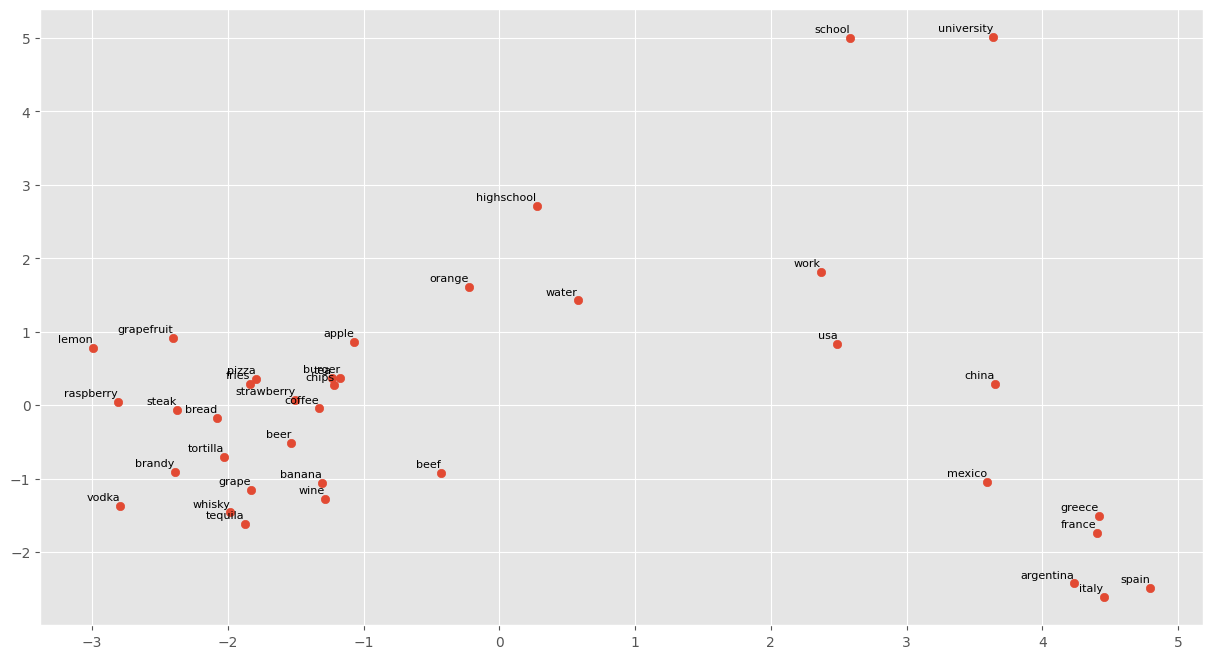

In [10]:
#
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


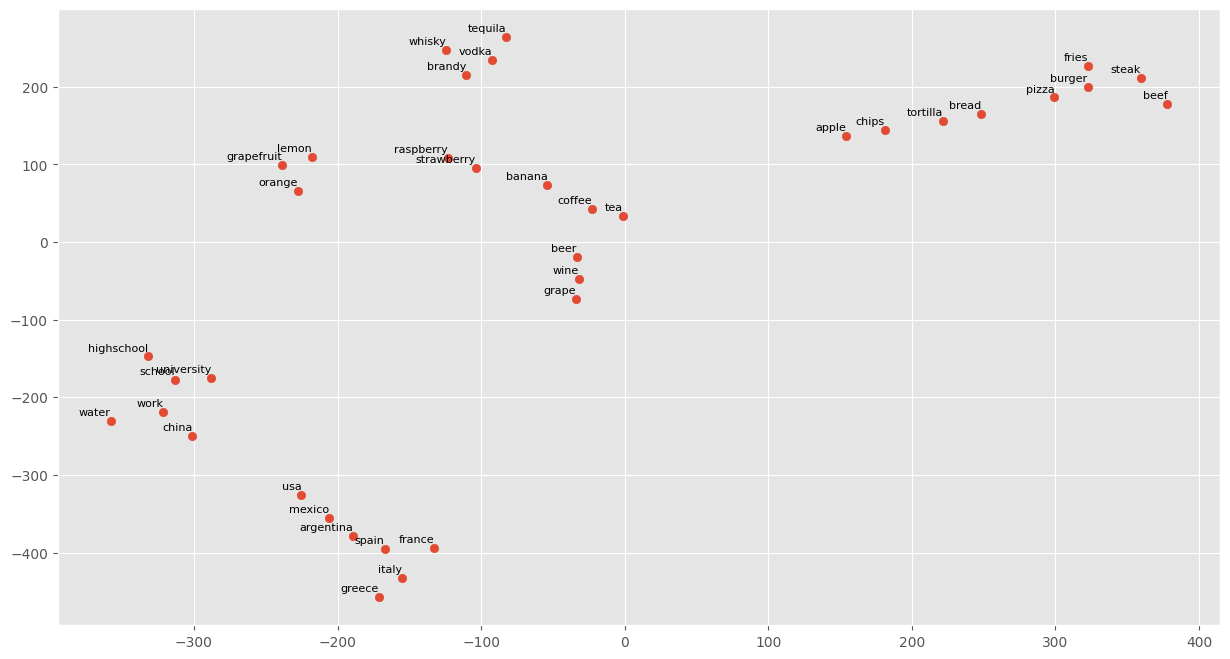

In [11]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

### Let us compute analogies

In [12]:
from pygments import token
# analogy
def analogy(word1, word2, word3, embeddings_dict):
    word1_vector= np.array(embeddings_dict[word1], dtype=float)
    word2_vector= np.array(embeddings_dict[word2], dtype=float)
    word3_vector= np.array(embeddings_dict[word3], dtype=float)
    tokens = list(embeddings_dict.keys())
    embedding_matrix = np.array(list(embeddings_dict.values()), dtype=float)

    query_vector = word2_vector - word1_vector + word3_vector

    # Normalize embeddings
    embedding_norms = embedding_matrix / norm(embedding_matrix, axis=1, keepdims=True)
    query_norm = query_vector / norm(query_vector)

    # Cosine similarity
    similarities = embedding_matrix @ query_vector

    # Get top-n indices
    top_indices = np.argsort(similarities)[-1:][::-1]

    print(word1, ' is to ', word2, ' as ', word3, ' is to ', tokens[top_indices[0]])
    return tokens[top_indices[0]]


In [13]:
analogy('mexico', 'mexican', 'spain', embeddings_dict)

mexico  is to  mexican  as  spain  is to  spanish


'spanish'

In [14]:
analogy('king', 'man', 'queen', embeddings_dict)

king  is to  man  as  queen  is to  woman


'woman'

In [15]:
# most similar
def find_most_similar(word, embeddings_dict, top_n=10, exclude=True):

  query_vector = np.array(embeddings_dict[word], dtype=float)
  tokens = list(embeddings_dict.keys())
  embedding_matrix = np.array(list(embeddings_dict.values()), dtype=float)

  # Normalize embeddings
  embedding_norms = embedding_matrix / norm(embedding_matrix, axis=1, keepdims=True)
  query_norm = query_vector / norm(query_vector)

  # Cosine similarity
  similarities = embedding_norms @ query_norm

  # Get top-n indices
  top_indices = np.argsort(similarities)[-(top_n+1):-1][::-1]

  return [(tokens[i], similarities[i]) for i in top_indices]

In [16]:
most_similar = find_most_similar('mexico', embeddings_dict)

In [17]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> peru
5 ---> guatemala
6 ---> argentina
7 ---> brazil
8 ---> chile
9 ---> bolivia
10 ---> america
